# Real Data Application

In this notebook, we analyze reconstructed individual patient data obtained from KM-GPT for multiple oncology trial subgroups.

Our goals are to:
1. load and harmonize the reconstructed IPD across studies
2. inspect treatment-arm structure and event/censoring patterns
3. construct a pooled real-data survival dataset
4. prepare the data for auxiliary-summary-based weighting and Bayesian nonparametric uncertainty quantification

These data are not true IPD; they are approximate IPD reconstructed from published Kaplan–Meier curves. The downstream analysis therefore treats reconstruction as an upstream step and focuses on the causal transport problem after reconstruction.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from lifelines import KaplanMeierFitter

base_path = "../data/raw/kmgpt_data/"

keynote = pd.read_csv(base_path + "keynote_high_pdl1_kmgpt.csv")
escort = pd.read_csv(base_path + "escort_high_pdl1_kmgpt.csv")
attr_low = pd.read_csv(base_path + "attraction3_low_pdl1_kmgpt.csv")
attr_high = pd.read_csv(base_path + "attraction3_high_pdl1_kmgpt.csv")

print("KEYNOTE-181:", keynote.shape)
print("ESCORT:", escort.shape)
print("ATTRACTION-3 low PD-L1:", attr_low.shape)
print("ATTRACTION-3 high PD-L1:", attr_high.shape)

KEYNOTE-181: (166, 5)
ESCORT: (191, 5)
ATTRACTION-3 low PD-L1: (216, 5)
ATTRACTION-3 high PD-L1: (203, 5)


In [3]:
datasets = {
    "keynote_high_pdl1": keynote,
    "escort_high_pdl1": escort,
    "attraction3_low_pdl1": attr_low,
    "attraction3_high_pdl1": attr_high,
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.head(3))
    print("columns:", df.columns.tolist())
    print("Group values:", df["Group"].unique())
    print("treat values:", sorted(df["treat"].unique()))
    print("curve values:", sorted(df["curve"].unique()))


keynote_high_pdl1
       time  status  treat         Group  curve
0  0.731707       1      1  Chemotherapy      0
1  0.890244       0      1  Chemotherapy      0
2  1.048780       1      1  Chemotherapy      0
columns: ['time', 'status', 'treat', 'Group', 'curve']
Group values: ['Chemotherapy' 'Pembrolizumab']
treat values: [np.int64(1), np.int64(2)]
curve values: [np.int64(0), np.int64(1)]

escort_high_pdl1
       time  status  treat         Group  curve
0  0.839286       1      1  Camrelizumab      0
1  0.910714       1      1  Camrelizumab      0
2  1.071429       1      1  Camrelizumab      0
columns: ['time', 'status', 'treat', 'Group', 'curve']
Group values: ['Camrelizumab' 'Chemotherapy']
treat values: [np.int64(1), np.int64(2)]
curve values: [np.int64(0), np.int64(1)]

attraction3_low_pdl1
       time  status  treat         Group  curve
0  0.346154       0      1  Chemotherapy      0
1  0.641026       1      1  Chemotherapy      0
2  1.192308       0      1  Chemotherapy      

In [4]:
# We will use Group as the treatment labeling, as treat is not consistent across trials. curve is an arm indicator
def standardize_kmgpt(df, trial_id, subgroup):
    out = df.copy()

    out = out.rename(columns={
        "status": "event",
        "Group": "arm_label",
    })

    out["trial_id"] = trial_id
    out["subgroup"] = subgroup

    # keep only relevant columns
    out = out[[
        "trial_id",
        "subgroup",
        "time",
        "event",
        "arm_label",
        "curve",
    ]].copy()

    return out


keynote_std = standardize_kmgpt(
    keynote,
    trial_id="KEYNOTE-181",
    subgroup="high_pdl1",
)

escort_std = standardize_kmgpt(
    escort,
    trial_id="ESCORT",
    subgroup="high_pdl1",
)

attr_low_std = standardize_kmgpt(
    attr_low,
    trial_id="ATTRACTION-3",
    subgroup="low_pdl1",
)

attr_high_std = standardize_kmgpt(
    attr_high,
    trial_id="ATTRACTION-3",
    subgroup="high_pdl1",
)

print(keynote_std.head())

      trial_id   subgroup      time  event     arm_label  curve
0  KEYNOTE-181  high_pdl1  0.731707      1  Chemotherapy      0
1  KEYNOTE-181  high_pdl1  0.890244      0  Chemotherapy      0
2  KEYNOTE-181  high_pdl1  1.048780      1  Chemotherapy      0
3  KEYNOTE-181  high_pdl1  1.243902      1  Chemotherapy      0
4  KEYNOTE-181  high_pdl1  1.365854      1  Chemotherapy      0


In [5]:
# Add binary treatment
def add_binary_treatment(df):
    out = df.copy()

    immunotherapy_labels = {
        "Pembrolizumab",
        "Camrelizumab",
        "Nivolumab",
    }

    out["treatment"] = out["arm_label"].apply(
        lambda x: 1 if x in immunotherapy_labels else 0
    )

    return out


keynote_std = add_binary_treatment(keynote_std)
escort_std = add_binary_treatment(escort_std)
attr_low_std = add_binary_treatment(attr_low_std)
attr_high_std = add_binary_treatment(attr_high_std)

for name, df in {
    "KEYNOTE-181": keynote_std,
    "ESCORT": escort_std,
    "ATTRACTION-3 low": attr_low_std,
    "ATTRACTION-3 high": attr_high_std,
}.items():
    print(f"\n{name}")
    print(df.groupby(["arm_label", "treatment"]).size())


KEYNOTE-181
arm_label      treatment
Chemotherapy   0            81
Pembrolizumab  1            85
dtype: int64

ESCORT
arm_label     treatment
Camrelizumab  1            93
Chemotherapy  0            98
dtype: int64

ATTRACTION-3 low
arm_label     treatment
Chemotherapy  0            107
Nivolumab     1            109
dtype: int64

ATTRACTION-3 high
arm_label     treatment
Chemotherapy  0            102
Nivolumab     1            101
dtype: int64


In [6]:
# harmonization
df_real = pd.concat(
    [keynote_std, escort_std, attr_low_std, attr_high_std],
    ignore_index=True,
)

print(df_real.shape)
df_real.head()

(776, 7)


,trial_id,subgroup,time,event,arm_label,curve,treatment
0,KEYNOTE-181,high_pdl1,0.731707,1,Chemotherapy,0,0
1,KEYNOTE-181,high_pdl1,0.890244,0,Chemotherapy,0,0
2,KEYNOTE-181,high_pdl1,1.048780,1,Chemotherapy,0,0
3,KEYNOTE-181,high_pdl1,1.243902,1,Chemotherapy,0,0
4,KEYNOTE-181,high_pdl1,1.365854,1,Chemotherapy,0,0


In [7]:
# summary sanity check
summary = (
    df_real.groupby(["trial_id", "subgroup", "arm_label"])
    .agg(
        n=("time", "size"),
        events=("event", "sum"),
        event_rate=("event", "mean"),
        median_time=("time", "median"),
    )
    .reset_index()
)

summary

,trial_id,subgroup,arm_label,n,events,event_rate,median_time
0,ATTRACTION-3,high_pdl1,Chemotherapy,102,89,0.872549,7.758621
1,ATTRACTION-3,high_pdl1,Nivolumab,101,76,0.752475,10.379310
2,ATTRACTION-3,low_pdl1,Chemotherapy,107,84,0.785047,8.000000
3,ATTRACTION-3,low_pdl1,Nivolumab,109,80,0.733945,10.538462
4,ESCORT,high_pdl1,Camrelizumab,93,67,0.720430,9.178571
5,ESCORT,high_pdl1,Chemotherapy,98,84,0.857143,6.330357
6,KEYNOTE-181,high_pdl1,Chemotherapy,81,69,0.851852,6.317073
7,KEYNOTE-181,high_pdl1,Pembrolizumab,85,68,0.800000,9.878049


Immunotherapy arms (Pembro, Camrel, Nivol) consistently have lower event rates and longer median survival, while chemotherapy arms have higher event rates and shorter medians, so KM-GPT reconstruction is behaving realistically. We will now do KM fit plots to see if curves seperate correctly by treatment, and verify no artifacts

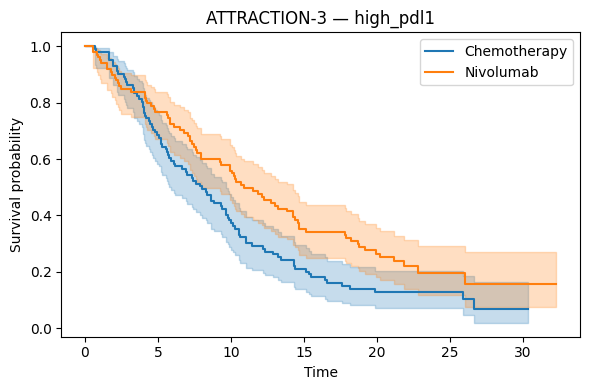

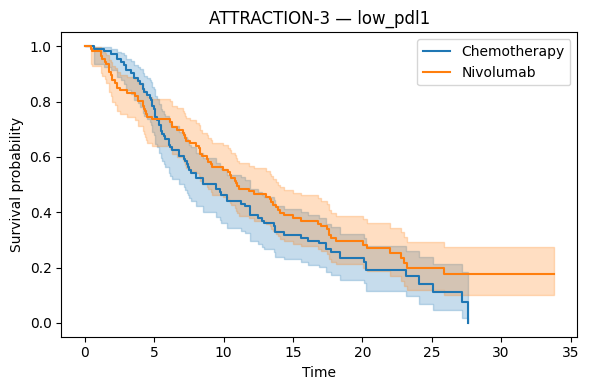

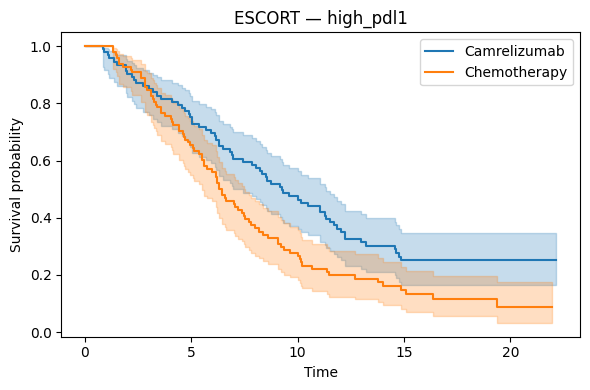

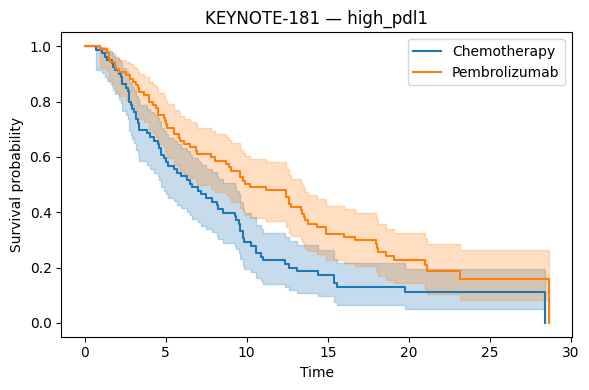

In [8]:
from lifelines import KaplanMeierFitter

for (trial_id, subgroup), g in df_real.groupby(["trial_id", "subgroup"]):
    plt.figure(figsize=(6, 4))

    for arm_label, sub in g.groupby("arm_label"):
        kmf = KaplanMeierFitter()
        kmf.fit(sub["time"], sub["event"], label=arm_label)
        kmf.plot()

    plt.title(f"{trial_id} — {subgroup}")
    plt.xlabel("Time")
    plt.ylabel("Survival probability")
    plt.tight_layout()
    plt.show()

In [9]:
from src.causal.estimands import pooled_survival_difference

pooled = pooled_survival_difference(df_real, t0=12.0)
pooled

,t0,S0,S1,Delta
0,12.0,0.280376,0.449162,0.168785


In [10]:
# saving baseline and combined data
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df_real.to_csv(output_dir / "real_kmgpt_ipd_harmonized.csv", index=False)
pooled.to_csv(output_dir / "naive_pooled_effect.csv", index=False)
print("Saved df_real to data/processed/")

Saved df_real to data/processed/
